## Exploratory Data Analysis

This notebook explores historical NFL player fantasy production to identify patterns that may be useful for predicting future full-PPR fantasy points.

In [1]:
import polars as pl

df = pl.read_csv("../data/processed/player_stats_clean_2016_2025.csv")

In [2]:
print(df.shape)
print(df.columns)

(5874, 33)
['player_id', 'player_display_name', 'position', 'season', 'recent_team', 'games', 'attempts', 'passing_yards', 'passing_tds', 'passing_interceptions', 'passing_2pt_conversions', 'carries', 'rushing_yards', 'rushing_tds', 'rushing_2pt_conversions', 'targets', 'receptions', 'receiving_yards', 'receiving_tds', 'receiving_2pt_conversions', 'fumbles_lost_total', 'sack_fumbles_lost', 'rushing_fumbles_lost', 'receiving_fumbles_lost', 'special_teams_tds', 'target_share', 'air_yards_share', 'wopr', 'fantasy_points', 'fantasy_points_ppr', 'calculated_fantasy_points_ppr', 'fantasy_points_ppr_calc', 'fantasy_points_difference']


In [3]:
# Summary by position

df.group_by("position").agg([
    pl.len().alias("player_seasons"),
    pl.col("fantasy_points_ppr_calc").mean().alias("avg_fantasy_points"),
    pl.col("fantasy_points_ppr_calc").median().alias("median_fantasy_points"),
    pl.col("fantasy_points_ppr_calc").max().alias("max_fantasy_points")
]).sort("position")

position,player_seasons,avg_fantasy_points,median_fantasy_points,max_fantasy_points
str,u32,f64,f64,f64
"""QB""",773,113.204735,60.66,430.38
"""RB""",1516,78.90781,44.15,471.2
"""TE""",1276,51.300486,29.45,316.3
"""WR""",2309,77.083534,48.0,439.5


In [4]:
# Summary by season

df.group_by("season").agg([
    pl.len().alias("player_seasons"),
    pl.col("fantasy_points_ppr_calc").mean().alias("avg_fantasy_points")
]).sort("season")

season,player_seasons,avg_fantasy_points
i64,u32,f64
2016,557,80.005637
2017,553,75.687125
2018,577,78.347348
2019,572,77.697413
2020,602,77.70598
2021,633,74.369352
2022,608,74.130954
2023,576,78.052708
2024,588,78.028605


# How stable are fantasy points from one season to the next?

In [5]:
# Are last season's fantasy points a good predictor of the next season's?

df = df.sort(["player_id", "season"])

df = df.with_columns(
    pl.col("fantasy_points_ppr_calc")
    .shift(1)
    .over("player_id")
    .alias("fantasy_points_lag_1")
)

In [6]:
yoy_df = df.filter(
    pl.col("fantasy_points_lag_1").is_not_null()
)

In [7]:
yoy_df.select(
    pl.corr(
        "fantasy_points_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("year_over_year_correlation")
)

year_over_year_correlation
f64
0.73127


Player fantasy production shows strong year over year persistence with a correlation of .73 between last season and current season full_PPR points. Lagged fantasy production may be an important baseline feature while still leaving room for other variables (age, team context, usage, efficiency) to improve predictions.

In [8]:
# Year over year correlation by position

yoy_df.group_by("position").agg(
    pl.corr(
        "fantasy_points_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("year_over_year_correlation")
).sort("position")

position,year_over_year_correlation
str,f64
"""QB""",0.717094
"""RB""",0.678682
"""TE""",0.734666
"""WR""",0.741443


Year over year fantasy production is moderately persistent across all four positions. Running backs show the lowest stability (0.68), while wide receivers and tight ends show the highest correlations (0.74 and 0.73). This suggests position specific models may be valuable because historical production carries different predictive strength by position.

# Total points or points per game?

In [9]:
# creating ppg

df = df.with_columns(
    (
        pl.col("fantasy_points_ppr_calc") / pl.col("games")
    ).alias("fantasy_ppg")
)

In [10]:
df = df.sort(["player_id", "season"])

df = df.with_columns(
    pl.col("fantasy_ppg")
    .shift(1)
    .over("player_id")
    .alias("fantasy_ppg_lag_1")
)

In [11]:
comparison_df = df.filter(
    pl.col("fantasy_ppg_lag_1").is_not_null()
)

comparison_df.select([
    pl.corr(
        "fantasy_points_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("prior_total_correlation"),

    pl.corr(
        "fantasy_ppg_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("prior_ppg_correlation")
])

prior_total_correlation,prior_ppg_correlation
f64,f64
0.73127,0.707345


Prior season total points are slightly more correlated with next season total points than prior season points per game (0.73 vs. 0.71). This suggests that both performance level and availability contribute meaningful predictive information, so future models should likely include both total and per game lagged features.

# Opportunity vs Efficiency

In [12]:
# Efficiency Metrics

df = df.with_columns([
    pl.when(pl.col("targets") > 0)
      .then(pl.col("receiving_yards") / pl.col("targets"))
      .otherwise(None)
      .alias("yards_per_target"),

    pl.when(pl.col("carries") > 0)
      .then(pl.col("rushing_yards") / pl.col("carries"))
      .otherwise(None)
      .alias("yards_per_carry")
])

In [13]:
# One year lags

df = df.sort(["player_id", "season"])

df = df.with_columns([
    pl.col("targets")
      .shift(1)
      .over("player_id")
      .alias("targets_lag_1"),

    pl.col("yards_per_target")
      .shift(1)
      .over("player_id")
      .alias("yards_per_target_lag_1"),

    pl.col("carries")
      .shift(1)
      .over("player_id")
      .alias("carries_lag_1"),

    pl.col("yards_per_carry")
      .shift(1)
      .over("player_id")
      .alias("yards_per_carry_lag_1")
])

In [14]:
# WRs and TEs

receivers = df.filter(
    pl.col("position").is_in(["WR", "TE"])
)

receivers.select([
    pl.corr(
        "targets_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("targets_correlation"),

    pl.corr(
        "yards_per_target_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("yards_per_target_correlation")
])

targets_correlation,yards_per_target_correlation
f64,f64
0.729744,0.177024


In [15]:
# RBs

running_backs = df.filter(
    pl.col("position") == "RB"
)

running_backs.select([
    pl.corr(
        "carries_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("carries_correlation"),

    pl.corr(
        "yards_per_carry_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("yards_per_carry_correlation")
])

carries_correlation,yards_per_carry_correlation
f64,f64
0.629559,0.186587


Prior year opportunity/volume metrics are substantially more predictive of next season fantasy production than efficiency metrics. For WRs and TEs, targets have a correlation of 0.73 with next season fantasy points, compared with just 0.18 for yards per target. For RBs, carries correlate at 0.63, compared with 0.19 for yards per carry. This suggests that future feature engineering should prioritize usage and opportunity over efficiency.

# Age and Fantasy Production by Position

In [16]:
import nflreadpy as nfl

seasons = list(range(2016,2026))

rosters = nfl.load_rosters(seasons=seasons)

print(rosters.shape)
print(rosters.columns)

(31005, 36)
['season', 'team', 'position', 'depth_chart_position', 'jersey_number', 'status', 'full_name', 'first_name', 'last_name', 'birth_date', 'height', 'weight', 'college', 'gsis_id', 'espn_id', 'sportradar_id', 'yahoo_id', 'rotowire_id', 'pff_id', 'pfr_id', 'fantasy_data_id', 'sleeper_id', 'years_exp', 'headshot_url', 'ngs_position', 'week', 'game_type', 'status_description_abbr', 'football_name', 'esb_id', 'gsis_it_id', 'smart_id', 'entry_year', 'rookie_year', 'draft_club', 'draft_number']


In [17]:
rosters.select([
    "gsis_id",
    "full_name",
    "season",
    "birth_date",
    "years_exp"
]).head()

gsis_id,full_name,season,birth_date,years_exp
str,str,i32,date,i32
"""00-0004091""","""Phil Dawson""",2016,1975-01-23,18
"""00-0016919""","""Adam Vinatieri""",2016,1972-12-28,20
"""00-0019435""","""Mike Leach""",2016,null,16
"""00-0019536""","""Shayne Graham""",2016,null,null
"""00-0019596""","""Tom Brady""",2016,1977-08-03,16


In [18]:
df.filter(
    pl.col("player_display_name") == "Aaron Rodgers"
).select([
    "player_id",
    "player_display_name",
    "season"
])

player_id,player_display_name,season
str,str,i64
"""00-0023459""","""Aaron Rodgers""",2016
"""00-0023459""","""Aaron Rodgers""",2017
"""00-0023459""","""Aaron Rodgers""",2018
"""00-0023459""","""Aaron Rodgers""",2019
"""00-0023459""","""Aaron Rodgers""",2020
"""00-0023459""","""Aaron Rodgers""",2021
"""00-0023459""","""Aaron Rodgers""",2022
"""00-0023459""","""Aaron Rodgers""",2023
"""00-0023459""","""Aaron Rodgers""",2024


In [19]:
rosters.filter(
    pl.col("full_name") == "Aaron Rodgers"
).select([
    "gsis_id",
    "full_name",
    "season",
    "birth_date",
    "years_exp"
])

gsis_id,full_name,season,birth_date,years_exp
str,str,i32,date,i32
"""00-0023459""","""Aaron Rodgers""",2016,1983-12-02,11
"""00-0023459""","""Aaron Rodgers""",2017,1983-12-02,12
"""00-0023459""","""Aaron Rodgers""",2018,1983-12-02,13
"""00-0023459""","""Aaron Rodgers""",2019,1983-12-02,14
"""00-0023459""","""Aaron Rodgers""",2020,1983-12-02,15
"""00-0023459""","""Aaron Rodgers""",2021,1983-12-02,16
"""00-0023459""","""Aaron Rodgers""",2022,1983-12-02,17
"""00-0023459""","""Aaron Rodgers""",2023,1983-12-02,18
"""00-0023459""","""Aaron Rodgers""",2024,1983-12-02,19


In [20]:
roster_season = (
    rosters
    .select([
        "season",
        "gsis_id",
        "full_name",
        "birth_date",
        "years_exp",
        "entry_year",
        "rookie_year",
        "draft_number"
    ])
    .unique(
        subset=["season", "gsis_id"],
        keep="first"
    )
)

print(roster_season.shape)

(31002, 8)


In [21]:
roster_duplicates = (
    roster_season
    .group_by(["gsis_id", "season"])
    .len()
    .filter(pl.col("len") > 1)
)

print("Duplicate roster player-seasons:", roster_duplicates.height)

Duplicate roster player-seasons: 0


In [22]:
df = df.join(
    roster_season,
    left_on=["player_id", "season"],
    right_on=["gsis_id", "season"],
    how="left"
)

In [23]:
df.filter(
    pl.col("birth_date").is_null()
).height

0

In [25]:
df = df.with_columns(
    (
        pl.date(pl.col("season"), 9, 1)
        - pl.col("birth_date")
    )
    .dt.total_days()
    .truediv(365.25)
    .alias("age")
)

In [26]:
df.select([
    "player_display_name",
    "position",
    "season",
    "birth_date",
    "age"
]).head(10)

player_display_name,position,season,birth_date,age
str,str,i64,date,f64
"""Tom Brady""","""QB""",2016,1977-08-03,39.080082
"""Tom Brady""","""QB""",2017,1977-08-03,40.079398
"""Tom Brady""","""QB""",2018,1977-08-03,41.078713
"""Tom Brady""","""QB""",2019,1977-08-03,42.078029
"""Tom Brady""","""QB""",2020,1977-08-03,43.080082
"""Tom Brady""","""QB""",2021,1977-08-03,44.079398
"""Tom Brady""","""QB""",2022,1977-08-03,45.078713
"""Steve Smith""","""WR""",2016,1979-05-12,37.308693
"""Drew Brees""","""QB""",2016,1979-01-15,37.629021


In [27]:
df.group_by("position").agg([
    pl.col("age").min().alias("min_age"),
    pl.col("age").mean().alias("avg_age"),
    pl.col("age").max().alias("max_age")
]).sort("position")

position,min_age,avg_age,max_age
str,f64,f64,f64
"""QB""",21.240246,28.557176,45.078713
"""RB""",20.616016,25.607555,37.303217
"""TE""",20.903491,26.626925,41.28679
"""WR""",20.774812,25.957835,37.976728


In [28]:
df = df.with_columns(
    pl.col("age")
    .floor()
    .cast(pl.Int64)
    .alias("age_year")
)

In [29]:
age_summary = (
    df.group_by(["position", "age_year"])
    .agg([
        pl.len().alias("player_seasons"),
        pl.col("fantasy_points_ppr_calc").mean().alias("avg_fantasy_points"),
        pl.col("fantasy_points_ppr_calc").median().alias("median_fantasy_points")
    ])
    .sort(["position", "age_year"])
)

age_summary

position,age_year,player_seasons,avg_fantasy_points,median_fantasy_points
str,i64,u32,f64,f64
"""QB""",21,12,123.126667,135.23
"""QB""",22,41,155.887317,156.38
"""QB""",23,69,131.606377,88.8
"""QB""",24,82,111.905854,62.27
"""QB""",25,75,104.121067,38.66
…,…,…,…,…
"""WR""",33,22,91.797273,59.75
"""WR""",34,12,82.13,68.7
"""WR""",35,8,66.035,34.55


In [30]:
age_summary.filter(
    pl.col("player_seasons") >= 10
)

position,age_year,player_seasons,avg_fantasy_points,median_fantasy_points
str,i64,u32,f64,f64
"""QB""",21,12,123.126667,135.23
"""QB""",22,41,155.887317,156.38
"""QB""",23,69,131.606377,88.8
"""QB""",24,82,111.905854,62.27
"""QB""",25,75,104.121067,38.66
…,…,…,…,…
"""WR""",30,82,88.452683,69.45
"""WR""",31,56,86.578214,53.45
"""WR""",32,38,81.877895,81.05


In [31]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [32]:
age_plot = (
    age_summary
    .filter(pl.col("player_seasons") >= 10)
    .to_pandas()
)

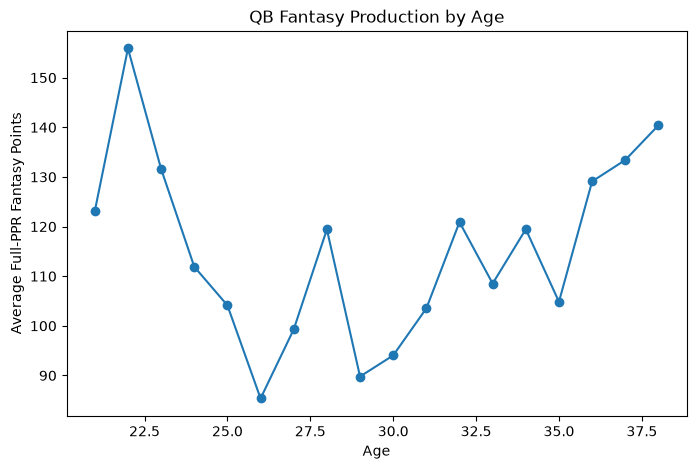

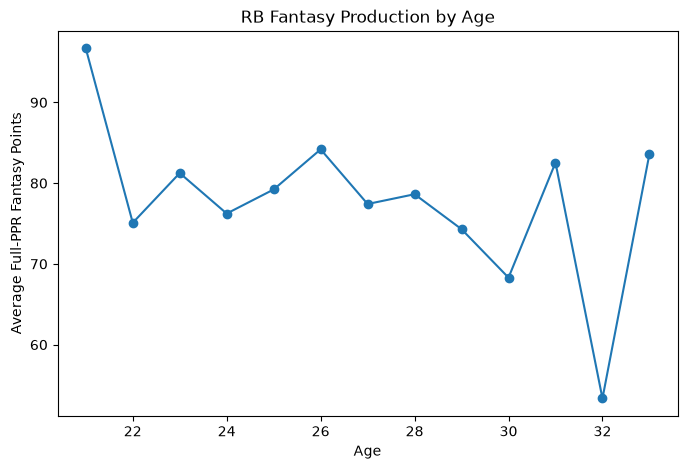

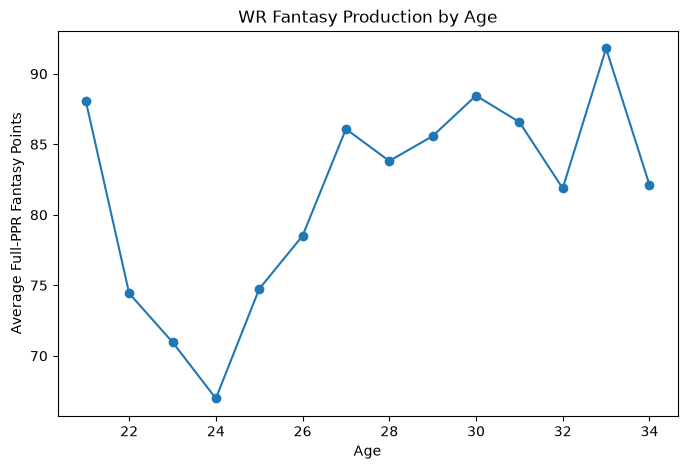

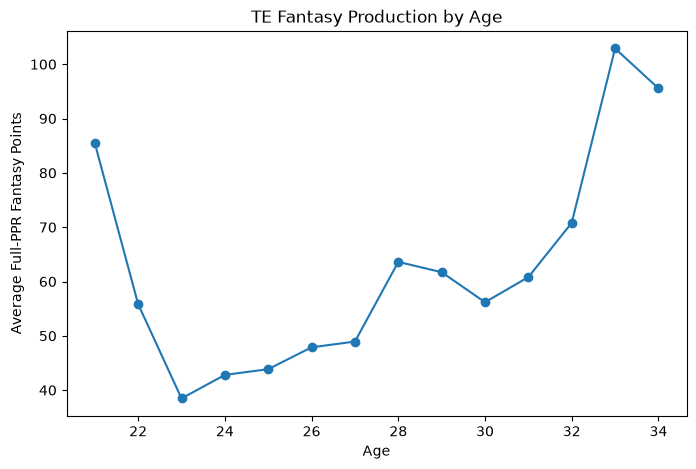

In [33]:
for position in ["QB", "RB", "WR", "TE"]:
    pos_data = age_plot[age_plot["position"] == position]

    plt.figure(figsize=(8, 5))

    plt.plot(
        pos_data["age_year"],
        pos_data["avg_fantasy_points"],
        marker="o"
    )

    plt.xlabel("Age")
    plt.ylabel("Average Full-PPR Fantasy Points")
    plt.title(f"{position} Fantasy Production by Age")

    plt.show()

Age appears to have a nonlinear relationship with fantasy production, and that relationship differs by position. Raw averages by age are noisy because older players who remain in the league tend to be higher quality survivors.

# Does Changing Teams Affect Production

In [34]:
df = df.sort(["player_id", "season"])

df = df.with_columns(
    pl.col("recent_team")
    .shift(1)
    .over("player_id")
    .alias("previous_team")
)

In [35]:
df = df.with_columns(
    (
        (pl.col("previous_team").is_not_null()) &
        (pl.col("recent_team") != pl.col("previous_team"))
    )
    .cast(pl.Int8)
    .alias("team_change_flag")
)

In [36]:
df.filter(
    pl.col("previous_team").is_not_null()
).group_by("team_change_flag").agg([
    pl.len().alias("player_seasons"),
    pl.col("fantasy_points_ppr_calc").mean().alias("avg_fantasy_points"),
    pl.col("fantasy_points_ppr_calc").median().alias("median_fantasy_points")
]).sort("team_change_flag")

team_change_flag,player_seasons,avg_fantasy_points,median_fantasy_points
i8,u32,f64,f64
0,2814,99.955856,71.59
1,1341,52.732274,24.4


In [37]:
df = df.with_columns(
    (
        pl.col("fantasy_points_ppr_calc")
        - pl.col("fantasy_points_lag_1")
    ).alias("fantasy_points_change")
)

In [38]:
df.filter(
    pl.col("previous_team").is_not_null()
).group_by("team_change_flag").agg([
    pl.len().alias("player_seasons"),
    pl.col("fantasy_points_change").mean().alias("avg_points_change"),
    pl.col("fantasy_points_change").median().alias("median_points_change")
]).sort("team_change_flag")

team_change_flag,player_seasons,avg_points_change,median_points_change
i8,u32,f64,f64
0,2814,-3.400547,-2.0
1,1341,-14.672543,-7.4


Players who changed teams experienced a larger average year-over-year decline in fantasy production than players who remained with the same team (-14.7 vs. -3.4 points). This suggests team continuity may contain useful predictive signal, although the relationship should not be interpreted causally because players who change teams may systematically differ from players who stay.

In [39]:
df.filter(
    pl.col("previous_team").is_not_null()
).group_by([
    "position",
    "team_change_flag"
]).agg([
    pl.len().alias("player_seasons"),
    pl.col("fantasy_points_change").mean().alias("avg_points_change"),
    pl.col("fantasy_points_change").median().alias("median_points_change")
]).sort([
    "position",
    "team_change_flag"
])

position,team_change_flag,player_seasons,avg_points_change,median_points_change
str,i8,u32,f64,f64
"""QB""",0,360,-2.782667,-6.65
"""QB""",1,218,-16.584037,-4.04
"""RB""",0,714,-4.04986,-3.7
"""RB""",1,341,-18.813842,-8.6
"""TE""",0,656,-1.670945,0.0
"""TE""",1,256,-4.403828,-1.2
"""WR""",0,1084,-4.22476,-1.6
"""WR""",1,526,-16.19327,-12.45


The relationship between changing teams and next-season fantasy production varies by position. Running backs, quarterbacks, and wide receivers who changed teams experienced substantially larger average declines than players who stayed, while the effect was much smaller for tight ends. This supports including a team-change indicator and potentially allowing its effect to vary by position.

# Target Share/Air Yard and Raw Targets for WR/TE

In [40]:
df = df.sort(["player_id", "season"])

df = df.with_columns([
    pl.col("target_share")
      .shift(1)
      .over("player_id")
      .alias("target_share_lag_1"),

    pl.col("air_yards_share")
      .shift(1)
      .over("player_id")
      .alias("air_yards_share_lag_1"),

    pl.col("wopr")
      .shift(1)
      .over("player_id")
      .alias("wopr_lag_1")
])

In [41]:
receivers = df.filter(
    pl.col("position").is_in(["WR", "TE"])
)

receivers.select([
    pl.corr(
        "targets_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("targets"),

    pl.corr(
        "target_share_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("target_share"),

    pl.corr(
        "air_yards_share_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("air_yards_share"),

    pl.corr(
        "wopr_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("wopr")
])

targets,target_share,air_yards_share,wopr
f64,f64,f64,f64
0.729744,0.730903,0.692448,0.72779


Prior-year receiving opportunity metrics are all strongly associated with next-season fantasy production. Target share (0.731) and WOPR (0.728) perform similarly to raw targets (0.730), while air yards share is slightly weaker (0.692). These metrics should be retained as candidate features because they may add contextual information about a player’s role within the offense.

In [42]:
receivers = df.filter(
    pl.col("position").is_in(["WR", "TE"])
)

receivers.select([
    pl.corr(
        "targets_lag_1",
        "targets"
    ).alias("targets_yoy"),

    pl.corr(
        "target_share_lag_1",
        "target_share"
    ).alias("target_share_yoy"),

    pl.corr(
        "air_yards_share_lag_1",
        "air_yards_share"
    ).alias("air_yards_share_yoy"),

    pl.corr(
        "wopr_lag_1",
        "wopr"
    ).alias("wopr_yoy")
])

targets_yoy,target_share_yoy,air_yards_share_yoy,wopr_yoy
f64,f64,f64,f64
0.752508,0.755619,0.76738,0.764043


Receiving opportunity metrics show strong year-over-year stability. Targets, target share, air yards share, and WOPR all have correlations around 0.75–0.77 with their following-season values. Combined with their strong relationship to future fantasy points, these metrics appear to be strong candidate predictors for WR and TE models.

# Games Played and Durability

In [43]:
df = df.sort(["player_id", "season"])

df = df.with_columns(
    pl.col("games")
    .shift(1)
    .over("player_id")
    .alias("games_lag_1")
)

In [44]:
df.filter(
    pl.col("games_lag_1").is_not_null()
).select([
    pl.corr(
        "games_lag_1",
        "games"
    ).alias("games_yoy_correlation"),

    pl.corr(
        "games_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("games_to_future_points")
])

games_yoy_correlation,games_to_future_points
f64,f64
0.491293,0.462527


In [45]:
df.filter(
    pl.col("games_lag_1").is_not_null()
).group_by("position").agg([
    pl.corr(
        "games_lag_1",
        "games"
    ).alias("games_yoy"),

    pl.corr(
        "games_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("games_to_future_points")
]).sort("position")

position,games_yoy,games_to_future_points
str,f64,f64
"""QB""",0.643514,0.653675
"""RB""",0.41164,0.412212
"""TE""",0.512905,0.520051
"""WR""",0.429672,0.452489


Prior-season games played provides meaningful predictive signal, especially for quarterbacks. Durability is only moderately persistent overall, suggesting availability should be included as a feature but not treated as highly deterministic. Running backs show the weakest year-over-year stability in games played, reinforcing the greater volatility of the position.

# Recent vs Older History

In [46]:
df = df.sort(["player_id", "season"])

df = df.with_columns(
    pl.col("fantasy_points_ppr_calc")
    .shift(2)
    .over("player_id")
    .alias("fantasy_points_lag_2")
)

In [47]:
lag_compare = df.filter(
    pl.col("fantasy_points_lag_2").is_not_null()
)

lag_compare.select([
    pl.corr(
        "fantasy_points_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("lag_1_correlation"),

    pl.corr(
        "fantasy_points_lag_2",
        "fantasy_points_ppr_calc"
    ).alias("lag_2_correlation")
])

lag_1_correlation,lag_2_correlation
f64,f64
0.733882,0.640013


In [48]:
lag_compare.group_by("position").agg([
    pl.corr(
        "fantasy_points_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("lag_1"),

    pl.corr(
        "fantasy_points_lag_2",
        "fantasy_points_ppr_calc"
    ).alias("lag_2")
]).sort("position")

position,lag_1,lag_2
str,f64,f64
"""QB""",0.723937,0.664705
"""RB""",0.678835,0.533612
"""TE""",0.737231,0.633346
"""WR""",0.7453,0.65114


Recent fantasy production is more predictive than older production. Prior-season fantasy points correlate more strongly with current-season points than production from two seasons earlier (0.73 vs. 0.64 overall). The decay is strongest for running backs, suggesting that recency should be emphasized more heavily for that position.

In [49]:
df = df.with_columns(
    (
        (
            pl.col("fantasy_points_lag_1")
            + pl.col("fantasy_points_lag_2")
        ) / 2
    ).alias("fantasy_points_2yr_avg")
)

In [50]:
two_year_compare = df.filter(
    pl.col("fantasy_points_lag_2").is_not_null()
)

two_year_compare.select([
    pl.corr(
        "fantasy_points_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("lag_1"),

    pl.corr(
        "fantasy_points_lag_2",
        "fantasy_points_ppr_calc"
    ).alias("lag_2"),

    pl.corr(
        "fantasy_points_2yr_avg",
        "fantasy_points_ppr_calc"
    ).alias("two_year_avg")
])

lag_1,lag_2,two_year_avg
f64,f64,f64
0.733882,0.640013,0.741431


In [51]:
two_year_compare.group_by("position").agg([
    pl.corr(
        "fantasy_points_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("lag_1"),

    pl.corr(
        "fantasy_points_lag_2",
        "fantasy_points_ppr_calc"
    ).alias("lag_2"),

    pl.corr(
        "fantasy_points_2yr_avg",
        "fantasy_points_ppr_calc"
    ).alias("two_year_avg")
]).sort("position")

position,lag_1,lag_2,two_year_avg
str,f64,f64,f64
"""QB""",0.723937,0.664705,0.753474
"""RB""",0.678835,0.533612,0.667547
"""TE""",0.737231,0.633346,0.738721
"""WR""",0.7453,0.65114,0.750541


Averaging the previous two seasons slightly improves predictive correlation overall, especially for QB, TE, and WR. For RBs, however, the most recent season remains more informative than a two-year average, reinforcing the importance of recency at that position.

In [52]:
df = df.with_columns(
    (
        0.7 * pl.col("fantasy_points_lag_1")
        + 0.3 * pl.col("fantasy_points_lag_2")
    ).alias("fantasy_points_2yr_weighted")
)

In [53]:
two_year_compare = df.filter(
    pl.col("fantasy_points_lag_2").is_not_null()
)

two_year_compare.select([
    pl.corr(
        "fantasy_points_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("lag_1"),

    pl.corr(
        "fantasy_points_2yr_avg",
        "fantasy_points_ppr_calc"
    ).alias("two_year_avg"),

    pl.corr(
        "fantasy_points_2yr_weighted",
        "fantasy_points_ppr_calc"
    ).alias("two_year_weighted")
])

lag_1,two_year_avg,two_year_weighted
f64,f64,f64
0.733882,0.741431,0.75192


In [54]:
two_year_compare.group_by("position").agg([
    pl.corr(
        "fantasy_points_lag_1",
        "fantasy_points_ppr_calc"
    ).alias("lag_1"),

    pl.corr(
        "fantasy_points_2yr_avg",
        "fantasy_points_ppr_calc"
    ).alias("two_year_avg"),

    pl.corr(
        "fantasy_points_2yr_weighted",
        "fantasy_points_ppr_calc"
    ).alias("two_year_weighted")
]).sort("position")

position,lag_1,two_year_avg,two_year_weighted
str,f64,f64,f64
"""QB""",0.723937,0.753474,0.75518
"""RB""",0.678835,0.667547,0.688177
"""TE""",0.737231,0.738721,0.751589
"""WR""",0.7453,0.750541,0.761562


A recency-weighted two-year fantasy production feature outperformed both prior-season production and a simple two-year average. Weighting the most recent season at 70% and the season before at 30% produced the strongest correlation with future fantasy points overall (0.75) and within each position. This supports using recency-weighted historical features in the modeling dataset.